In [11]:
#run under xtb_uma environment
import os

import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import EnumerateStereoisomers
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdMolAlign

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
def enumerate_stereoisomers(smiles_list) -> list:
    
    all_isomers = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        Chem.SanitizeMol(mol)
        current_isomers = list(EnumerateStereoisomers(mol))
        if len(current_isomers) > 1:
            print(f"{len(current_isomers)} stereoisomers found for {smiles}")
        all_isomers.extend(current_isomers)
        isomers = list(set(all_isomers))
        isomers = list(sorted(isomers, key=lambda x: Descriptors.MolWt(x)))
        print(f"Number of unique stereoisomers generated: {len(isomers)}")
    
    return isomers

In [5]:
enumerated_isomers = enumerate_stereoisomers(pd.read_csv('../covalency_classification/final_dataset_for_classification_only_crbn.csv')['smiles'].tolist())
print(f"Total enumerated isomers: {len(enumerated_isomers)}")

2 stereoisomers found for O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1
Number of unique stereoisomers generated: 2
2 stereoisomers found for O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1
Number of unique stereoisomers generated: 4
2 stereoisomers found for CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Number of unique stereoisomers generated: 6
2 stereoisomers found for CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Number of unique stereoisomers generated: 8
2 stereoisomers found for O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1
Number of unique stereoisomers generated: 10
2 stereoisomers found for CCCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Number of unique stereoisomers generated: 12
2 stereoisomers found for CC(C)NC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Number of unique stereoisomers generated: 14
4 stereoisomers found for CC(C#N)NC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Number of unique stereoisomers generated: 18
2 stereoisomers found for CC1(NC(=O)c2ccc3c(c2)CN(C2CCC(=O)NC2=O)C3=O)CC1
Number of unique st

In [ ]:
def conformer_generation_by_ETKDG(mols, mpi_cores, conf_gene_count, output_folder_path):

    ps = AllChem.ETKDGv3() 
    ps.numThreads = int(mpi_cores)

    os.makedirs(output_folder_path, exist_ok=True)
        
    for t, i in enumerate(mols):
        energy_dict = {}
        mol_H = Chem.AddHs(i)
        AllChem.EmbedMultipleConfs(mol_H, conf_gene_count, ps)
        try:

            res = AllChem.MMFFOptimizeMoleculeConfs(mol_H, maxIters=1000)
        
            for x, y in enumerate(res):
                energy_dict[x] = y

            # Sort conformers by energy (lowest first)
            sorted_energy_dict = {k: v for k, v in sorted(energy_dict.items(), key=lambda item: item[1][-1])}
            
            kept_conf_ids = []
            conf_gm_energy = None

            # Filter conformers: Keep if converged AND rmsd > 1.0A from all already kept conformers
            for conf_id, (not_converged, energy) in sorted_energy_dict.items():
                if not_converged == 0:
                    if not kept_conf_ids:
                        # Always keep the Global Minimum (first valid conformer)
                        kept_conf_ids.append(conf_id)
                        conf_gm_energy = energy
                    else:
                        # Check RMSD against all previously kept conformers
                        is_distinct = True
                        for kept_id in kept_conf_ids:
                            # rdMolAlign.GetBestRMS(probeMol, refMol, probeId, refId)
                            # We align the candidate (conf_id) to the kept conformer (kept_id)
                            rms = rdMolAlign.GetBestRMS(mol_H, mol_H, conf_id, kept_id)
                            if rms < 1.0:
                                is_distinct = False
                                break
                        
                        if is_distinct:
                            kept_conf_ids.append(conf_id)

            # Proceed if we found at least one converged conformer
            if kept_conf_ids:
                
                ligand_sdf_path = os.path.join(output_folder_path, f'ligand_{str(t)}.sdf')
                writer = Chem.SDWriter(ligand_sdf_path)

                for cid in kept_conf_ids:
                    # Set specific energy for this conformer
                    current_energy = energy_dict[cid][1]
                    mol_H.SetProp('conf_energy', str(current_energy))
                    # retain the GM energy property on all ensuring context
                    mol_H.SetProp('conf_gm_energy', str(conf_gm_energy))
                    
                    writer.write(mol_H, confId=cid)
                
                writer.close()

        except Exception as e:
            print(f"Error processing molecule {t}: {e}")
            continue

conformer_generation_by_ETKDG(enumerated_isomers, mpi_cores=16, conf_gene_count=50, output_folder_path='etkdg_mmff_conformers')

Error processing molecule 15: Bad Conformer Id
Error processing molecule 16: Bad Conformer Id
Error processing molecule 32: Bad Conformer Id
Error processing molecule 68: Bad Conformer Id
Error processing molecule 397: Bad Conformer Id
Error processing molecule 422: Bad Conformer Id
Error processing molecule 600: Bad Conformer Id
Error processing molecule 936: Bad Conformer Id
Error processing molecule 995: Bad Conformer Id
Error processing molecule 1203: Bad Conformer Id
Error processing molecule 1321: Bad Conformer Id
Error processing molecule 1322: Bad Conformer Id
Error processing molecule 1323: Bad Conformer Id
Error processing molecule 1324: Bad Conformer Id
Error processing molecule 1333: Bad Conformer Id
Error processing molecule 1334: Bad Conformer Id
Error processing molecule 1335: Bad Conformer Id
Error processing molecule 1336: Bad Conformer Id
Error processing molecule 1618: Bad Conformer Id
Error processing molecule 2020: Bad Conformer Id
Error processing molecule 2313: B

In [3]:
# check if any ligand in the output folder match a defined smiles
smiles = 'O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1'
ref_mol = Chem.MolFromSmiles(smiles)
con_smiles = Chem.MolToSmiles(ref_mol, isomericSmiles=False, canonical=True)
    
for filename in os.listdir('etkdg_mmff_conformers'):
    if filename.endswith('.sdf'):
        sdf_path = os.path.join('etkdg_mmff_conformers', filename)
        suppl = Chem.SDMolSupplier(sdf_path)
        # We only check the first conformer in each SDF file for simplicity
        mol_smiles = Chem.MolToSmiles(suppl[0], isomericSmiles=False, canonical=True)
        if mol_smiles == con_smiles:
            print(f"Found a match in {filename} with SMILES: {mol_smiles}")

Found a match in ligand_3121.sdf with SMILES: O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1
Found a match in ligand_3122.sdf with SMILES: O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1


In [4]:
smiles = 'O=C1CCC(N2Cc3ccccc3C2=O)C(=O)N1'
ref_mol = Chem.MolFromSmiles(smiles)
con_smiles = Chem.MolToSmiles(ref_mol, isomericSmiles=False, canonical=True)
    
for filename in os.listdir('etkdg_mmff_conformers'):
    if filename.endswith('.sdf'):
        sdf_path = os.path.join('etkdg_mmff_conformers', filename)
        suppl = Chem.SDMolSupplier(sdf_path)
        # We only check the first conformer in each SDF file for simplicity
        mol_smiles = Chem.MolToSmiles(suppl[0], isomericSmiles=False, canonical=True)
        if mol_smiles == con_smiles:
            print(f"Found a match in {filename} with SMILES: {mol_smiles}")

Found a match in ligand_249.sdf with SMILES: O=C1CCC(N2Cc3ccccc3C2=O)C(=O)N1
Found a match in ligand_250.sdf with SMILES: O=C1CCC(N2Cc3ccccc3C2=O)C(=O)N1


In [1]:
import subprocess
import shutil
import glob
import re
import os
import pandas as pd
from rdkit import Chem

# Set the path to the XTB executable in the xtb_uma environment
XTB_PATH = "/home/haolan/anaconda3/envs/xtb_uma/bin/xtb"

def run_xtb_optimization(mol, conf_id, file_id):
    """
    Runs xtb optimization for a single RDKit Mol object.
    Returns:
        opt_mol: RDKit Mol object with optimized geometry
        properties: Dictionary of properties (Energy, HOMO, LUMO, Gap)
    """
    # Create a temporary directory for the calculation
    temp_dir = f"temp_xtb_{file_id}_{conf_id}"
    os.makedirs(temp_dir, exist_ok=True)
    
    original_dir = os.getcwd()
    
    properties = {
        'initial_conf_id': conf_id,
        'xtb_energy_eh': None,
        'xtb_homo_ev': None,
        'xtb_lumo_ev': None,
        'xtb_gap_ev': None,
        'converged': False
    }
    
    opt_mol = None

    try:
        os.chdir(temp_dir)

        # Write the molecule to an SDF file
        # xtb GFN2 optimizes reasonably well from SDF
        sdf_file = "input.sdf"
        writer = Chem.SDWriter(sdf_file)
        writer.write(mol)
        writer.close()

        # Command to run xtb
        # --opt: Geometry optimization
        # --gfn 2: GFN2-xTB method (default)
        cmd = [XTB_PATH, sdf_file, "--opt", "--gfn", "2"]
        
        # Set environment variables
        # Using a limited number of threads per job can be better if we were to parallelize the loop,
        # but here we run sequentially so we can allow xtb to use a few threads.
        env = os.environ.copy()
        env['OMP_NUM_THREADS'] = '4' 
        env['MKL_NUM_THREADS'] = '4'
        env['OMP_STACKSIZE'] = '4G' 
        
        # Run xtb
        result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, env=env)
        
        output = result.stdout
        
        # Parse output
        
        # Check convergence
        if "GEOMETRY OPTIMIZATION CONVERGED" in output:
            properties['converged'] = True
            
        # Parse Energy (Final energy)
        # Pattern: "TOTAL ENERGY              -35.424362142728 Eh"
        energy_match = re.findall(r"TOTAL ENERGY\s+([-+]?\d*\.\d+)\s+Eh", output)
        if energy_match:
            properties['xtb_energy_eh'] = float(energy_match[-1])
            
        # Parse HOMO, LUMO, Gap
        # Pattern: "HOMO-LUMO Gap              4.3210001234 eV"
        gap_match = re.search(r"HOMO-LUMO Gap\s+([-+]?\d*\.\d+)\s+eV", output)
        if gap_match:
            properties['xtb_gap_ev'] = float(gap_match.group(1))
            
        # HOMO/LUMO from table
        # We look for lines like:
        #   11     2.0000           -0.350000             -9.5240  (HOMO)
        #   12                      -0.120000             -3.2654  (LUMO)
        homo_match = re.search(r"\s+2\.0000\s+[-0-9.]+\s+([-0-9.]+)\s+\(HOMO\)", output)
        if homo_match:
            properties['xtb_homo_ev'] = float(homo_match.group(1))
            
        lumo_match = re.search(r"\s+[-0-9.]+\s+[-0-9.]+\s+([-0-9.]+)\s+\(LUMO\)", output)
        # Sometimes LUMO occupancy is 0.0000 explicitly
        if not lumo_match:
            lumo_match = re.search(r"\s+0\.0000\s+[-0-9.]+\s+([-0-9.]+)\s+\(LUMO\)", output)
            
        if lumo_match:
            properties['xtb_lumo_ev'] = float(lumo_match.group(1))
            
        # Read optimized geometry from xtbopt.sdf
        if os.path.exists("xtbopt.sdf"):
            suppl = Chem.SDMolSupplier("xtbopt.sdf", removeHs=False)
            if len(suppl) > 0:
                opt_mol = suppl[0]
                # Transfer properties from original mol
                for prop in mol.GetPropNames():
                    opt_mol.SetProp(prop, mol.GetProp(prop))
                
                # Add new properties
                for k, v in properties.items():
                    if v is not None:
                        opt_mol.SetProp(k, str(v))

    except Exception as e:
        print(f"Error optimizing {file_id} conf {conf_id}: {e}")
    finally:
        os.chdir(original_dir)
        # Clean up temp directory
        try:
             shutil.rmtree(temp_dir)
        except:
             pass

    return opt_mol, properties

# Main processing loop
input_folder = 'etkdg_mmff_conformers'
output_folder = 'xtb_optimized_conformers'
os.makedirs(output_folder, exist_ok=True)

sdf_files = sorted(glob.glob(os.path.join(input_folder, 'ligand_*.sdf')))
print(f"Found {len(sdf_files)} SDF files to process.")

all_results = []

# Iterate over each ligand file
for sdf_path in sdf_files:
    filename = os.path.basename(sdf_path)
    file_id = filename.replace('ligand_', '').replace('.sdf', '')
    
    suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
    
    output_sdf_path = os.path.join(output_folder, filename)
    writer = Chem.SDWriter(output_sdf_path)
    
    print(f"Processing {filename}...")
    
    for i, mol in enumerate(suppl):
        if mol is None:
            continue
            
        # Run optimization
        opt_mol, props = run_xtb_optimization(mol, i, file_id)
        
        if opt_mol:
            writer.write(opt_mol)
            
            # Add metadata to results
            props['filename'] = filename
            props['molecule_id'] = file_id
            
            # Also grab properties from the molecule if needed (like original MMFF energy)
            if mol.HasProp('conf_energy'):
                props['mmff_energy'] = mol.GetProp('conf_energy')
            if mol.HasProp('conf_gm_energy'):
                props['mmff_gm_energy'] = mol.GetProp('conf_gm_energy')
                
            all_results.append(props)
            
    writer.close()

# Save results to CSV
df_results = pd.DataFrame(all_results)
df_results.to_csv('xtb_optimization_results.csv', index=False)
print("Processing complete. Results saved to xtb_optimization_results.csv")
print(df_results.head())


Found 16623 SDF files to process.
Processing ligand_0.sdf...
Processing ligand_1.sdf...
Processing ligand_10.sdf...
Processing ligand_100.sdf...
Processing ligand_1000.sdf...
Processing ligand_10000.sdf...
Processing ligand_10001.sdf...
Processing ligand_10002.sdf...
Processing ligand_10003.sdf...
Processing ligand_10004.sdf...
Processing ligand_10005.sdf...
Processing ligand_10006.sdf...
Processing ligand_10007.sdf...
Processing ligand_10008.sdf...
Processing ligand_10009.sdf...
Processing ligand_1001.sdf...
Processing ligand_10010.sdf...
Processing ligand_10011.sdf...
Processing ligand_10012.sdf...
Processing ligand_10013.sdf...
Processing ligand_10014.sdf...
Processing ligand_10015.sdf...
Processing ligand_10016.sdf...
Processing ligand_10017.sdf...
Processing ligand_10018.sdf...
Processing ligand_10019.sdf...
Processing ligand_1002.sdf...
Processing ligand_10020.sdf...
Processing ligand_10021.sdf...
Processing ligand_10022.sdf...
Processing ligand_10023.sdf...
Processing ligand_100

In [7]:
# Cell to run UMA single point energy and calculate Boltzmann averaged properties

import os
import glob
import sys
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import torch

# Define variables initially to avoid NameError if imports fail
OCPCalculator = None
FAIRChemCalculator = None
load_predict_unit = None
get_predict_unit = None
available_models = []

print("Setting up calculation environment...")
print(f"Current working directory: {os.getcwd()}")
print(f"CUDA Available: {torch.cuda.is_available()}")

# 1. Try Imports
try:
    from ase import Atoms
    from ase.units import kB, Hartree, eV
    print("ASE imported successfully.")
    
    # Try New FairChem API
    try:
        from fairchem.core.calculate.ase_calculator import FAIRChemCalculator
        from fairchem.core.calculate.pretrained_mlip import get_predict_unit, available_models
        from fairchem.core.units.mlip_unit import load_predict_unit
        print("FAIRChem (New API) imported successfully.")
    except ImportError as e1:
        print(f"FAIRChem New API import failed: {e1}")
        # Try Legacy OCP API
        try:
            from fairchem.core.common.relaxation import OCPCalculator
            print("FairChem (Legacy OCP API) imported successfully.")
        except ImportError as e2:
            print(f"Legacy OCP API import failed: {e2}")
            print("CRITICAL: Could not import any calculator from fairchem-core.")

except ImportError as e:
    print(f"CRITICAL: Error importing base dependencies (ASE): {e}")


def rdkit_to_ase(mol):
    """
    Convert an RDKit molecule to an ASE Atoms object.
    """
    pos = mol.GetConformer().GetPositions()
    atom_nums = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    return Atoms(numbers=atom_nums, positions=pos)

def get_boltzmann_weights(energies_ev, temperature_K=298.15):
    """
    Calculate Boltzmann weights from energies in eV.
    """
    # kB in eV/K
    k = 8.617333262e-5 
    kT = k * temperature_K
    
    # Shift energies to avoid numerical issues (set min energy to 0 temporarily)
    energies = np.array(energies_ev)
    min_e = np.min(energies)
    rel_energies = energies - min_e
    
    weights = np.exp(-rel_energies / kT)
    Z = np.sum(weights)
    return weights / Z

def run_uma_workflow(input_folder, model_checkpoint="uma-s-1p1.pt", device="cuda"):
    """
    Runs UMA SPE on conformers in the input folder and calculates Boltzmann averaged properties.
    Args:
        model_checkpoint: Path to local .pt file or model name.
        device: 'cuda' or 'cpu'.
    """
    
    calc = None
    output_csv = 'uma_boltzmann_averaged_results.csv'

    # Check dependencies
    if FAIRChemCalculator is None and OCPCalculator is None:
        print("Error: No valid Calculator class found. Please check imports.")
        return

    # Check model file
    if os.path.exists(model_checkpoint):
        print(f"Found local model file: {model_checkpoint}")
    else:
        print(f"Model file '{model_checkpoint}' not found in {os.getcwd()}")
        # Check if it was meant to be a download name
        if model_checkpoint not in available_models:
             print("And it does not match known downloadable models.")

    # Setup Calculator
    if FAIRChemCalculator:
        try:
            if device == "cuda" and not torch.cuda.is_available():
                print("Warning: CUDA requested but not available. Fallback to CPU might happen.")
            
            predict_unit = None
            
            # 1. Check if it is a local file
            if os.path.exists(model_checkpoint):
                print(f"Loading local checkpoint from: {model_checkpoint}")
                if load_predict_unit:
                    predict_unit = load_predict_unit(model_checkpoint, device=device)
                else:
                    print("Error: load_predict_unit function is not available.")
                    return
            else:
                # 2. Treat as model name
                target_model = model_checkpoint
                if model_checkpoint == "uma":
                     target_model = "uma-m-1p1"
                
                if target_model in available_models and get_predict_unit:
                     print(f"Attempting to download/load model: {target_model}")
                     predict_unit = get_predict_unit(target_model, device=device)
                else:
                     print(f"Model '{model_checkpoint}' not found locally or in available models.")
                     return

            # Initialize Calculator
            calc = FAIRChemCalculator(predict_unit, task_name="omol")
            print("FAIRChemCalculator initialized successfully.")
            
        except Exception as e:
            print(f"Failed to load FAIRChem model '{model_checkpoint}': {e}")
            import traceback
            traceback.print_exc()
            return

    elif OCPCalculator:
        print(f"Using legacy OCP API. Model: {model_checkpoint}")
        try:
            use_cpu = (device == "cpu") or (not torch.cuda.is_available())
            calc = OCPCalculator(checkpoint=model_checkpoint, cpu=use_cpu)
        except Exception as e:
            print(f"Failed to load Legacy OCP model '{model_checkpoint}': {e}")
            return

    # Process files
    if not os.path.isdir(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist.")
        return

    sdf_files = sorted(glob.glob(os.path.join(input_folder, 'ligand_*.sdf')))
    print(f"Found {len(sdf_files)} SDF files in {input_folder} to process.")
    
    # Check for existing results to recover
    processed_filenames = set()
    if os.path.exists(output_csv):
        try:
            # Check if file has content
            if os.path.getsize(output_csv) > 0:
                df_existing = pd.read_csv(output_csv)
                if 'filename' in df_existing.columns:
                    processed_filenames = set(df_existing['filename'].astype(str).tolist())
                print(f"Found {len(processed_filenames)} already processed molecules in {output_csv}.")
            else:
                print(f"{output_csv} exists but is empty.")
        except Exception as e:
            print(f"Error reading existing results file: {e}")
            print("Will append to it anyway, hopefully structure matches.")

    results = [] # To keep track of newly processed in this session if needed, though we append to file.

    for sdf_path in sdf_files:
        filename = os.path.basename(sdf_path)
        
        if filename in processed_filenames:
            continue
            
        file_id = filename.replace('ligand_', '').replace('.sdf', '') # filename used as ID
        
        # Load all conformers
        try:
            suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
            mols = [m for m in suppl if m is not None]
        except Exception as e:
            print(f"Error reading SDF {filename}: {e}")
            continue
        
        if not mols:
            continue
            
        print(f"Processing {len(mols)} conformers for {file_id} ({filename})...")
        
        mol_data = [] # Store data for this molecule's conformers
        
        for i, mol in enumerate(mols):
            # 1. Get XTB Properties (assuming they are stored in SD props from previous step)
            try:
                xtb_homo = float(mol.GetProp('xtb_homo_ev'))
                xtb_lumo = float(mol.GetProp('xtb_lumo_ev'))
                xtb_gap = xtb_lumo - xtb_homo
                xtb_energy = float(mol.GetProp('xtb_energy_eh')) # In Hartree
            except KeyError:
                print(f"Missing XTB properties for {file_id} conf {i}. Skipping.")
                continue

            # 2. Convert to ASE and Run UMA
            try:
                atoms = rdkit_to_ase(mol)
                atoms.calc = calc
                uma_energy_ev = atoms.get_potential_energy() # ASE returns eV
            except Exception as e:
                print(f"Error running UMA for {file_id} conf {i}: {e}")
                uma_energy_ev = np.nan
            
            mol_data.append({
                'conf_id': i,
                'xtb_homo_ev': xtb_homo,
                'xtb_lumo_ev': xtb_lumo,
                'xtb_gap_ev': xtb_gap,
                'uma_energy_ev': uma_energy_ev
            })

        # 3. Calculate Boltzmann Averages
        df_mol = pd.DataFrame(mol_data)
        df_mol = df_mol.dropna(subset=['uma_energy_ev'])
        
        if df_mol.empty:
            print(f"No valid UMA energies for {file_id}.")
            continue
            
        weights = get_boltzmann_weights(df_mol['uma_energy_ev'].values)
        df_mol['weight'] = weights
        
        avg_homo = np.average(df_mol['xtb_homo_ev'], weights=weights)
        avg_lumo = np.average(df_mol['xtb_lumo_ev'], weights=weights)
        avg_gap = np.average(df_mol['xtb_gap_ev'], weights=weights)
        
        # Determine Global Minimum based on UMA
        min_idx = df_mol['uma_energy_ev'].idxmin()
        gm_uma_energy = df_mol.loc[min_idx, 'uma_energy_ev']
        
        result_entry = {
            'molecule_id': file_id,
            'filename': filename,
            'avg_homo_ev': avg_homo,
            'avg_lumo_ev': avg_lumo,
            'avg_gap_ev': avg_gap,
            'gm_uma_energy_ev': gm_uma_energy,
            'num_conformers': len(df_mol)
        }
        
        results.append(result_entry)
        
        # Incremental Save
        df_entry = pd.DataFrame([result_entry])
        write_header = not os.path.exists(output_csv) or os.path.getsize(output_csv) == 0
        df_entry.to_csv(output_csv, mode='a', header=write_header, index=False)

    print(f"Job finished.")
    if os.path.exists(output_csv):
        print(f"Total results in {output_csv}:")
        final_df = pd.read_csv(output_csv)
        print(final_df.shape)
        with pd.option_context('display.max_columns', None):
            print(final_df.tail()) # Printing tail to show recent additions

# Run the workflow
# Using the local file 'uma-s-1p1.pt'
if __name__ == "__main__":
    run_uma_workflow('xtb_optimized_conformers', model_checkpoint="uma-s-1p1.pt", device="cuda")


Setting up calculation environment...
Current working directory: /mnt/d/blog_in_progress/QM_calculation
CUDA Available: True
ASE imported successfully.


/home/haolan/anaconda3/envs/xtb_uma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-21 09:29:25,551	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


FAIRChem (New API) imported successfully.


In [10]:
# Custom analysis for ligand_249 and ligand_3122
import os
import pandas as pd
import numpy as np
from rdkit import Chem
from ase import Atoms
import torch

# Ensure Calculator functions are available (fallback if previous cells didn't run)
try:
    from fairchem.core.calculate.ase_calculator import FAIRChemCalculator
    from fairchem.core.units.mlip_unit import load_predict_unit
except ImportError:
    FAIRChemCalculator = None
    load_predict_unit = None

def get_energies_and_boltzmann(ligand_id, mmff_folder, xtb_folder, calc=None):
    print(f"\n{'='*40}")
    print(f"Analyzing {ligand_id}")
    print(f"{'='*40}")
    
    # helper for boltzmann
    def calculate_boltzmann_weights_and_rel(energies_val, temperature_K=298.15, unit_to_ev=1.0):
        # k_B in eV/K
        k_ev = 8.617333262e-5 
        kT = k_ev * temperature_K
        
        energies_ev = np.array(energies_val) * unit_to_ev
        
        # Filter NaNs
        valid_indices = ~np.isnan(energies_ev)
        if not np.any(valid_indices):
             return np.full_like(energies_ev, np.nan), np.full_like(energies_ev, np.nan)
             
        min_e = np.min(energies_ev[valid_indices])
        rel_energies_ev = energies_ev - min_e
        
        weights = np.zeros_like(energies_ev)
        # only calc weights for valid
        weights[valid_indices] = np.exp(-rel_energies_ev[valid_indices] / kT)
        
        z = np.sum(weights)
        if z == 0: return weights, rel_energies_ev
        return weights / z, rel_energies_ev

    # 1. MMFF Analysis
    mmff_path = os.path.join(mmff_folder, f"{ligand_id}.sdf")
    if os.path.exists(mmff_path):
        suppl = Chem.SDMolSupplier(mmff_path, removeHs=False)
        print(f"Found MMFF SDF: {mmff_path}")
        
        mmff_data = []
        for i, mol in enumerate(suppl):
            if mol is None: continue
            
            # MMFF Energy (stored as 'conf_energy' which is usually kcal/mol)
            e_mmff = float(mol.GetProp('conf_energy')) if mol.HasProp('conf_energy') else np.nan
            
            # UMA Energy on MMFF Geometry
            e_uma = np.nan
            if calc:
                try:
                    atoms = rdkit_to_ase(mol) # Helper function from previous cells assumed available
                    atoms.calc = calc
                    e_uma = atoms.get_potential_energy()
                except Exception as e:
                    print(f"  UMA Calc Error (Conf {i}): {e}")
            
            mmff_data.append({'conf_id': i, 'mmff_kcal': e_mmff, 'uma_ev': e_uma})

        df_mmff = pd.DataFrame(mmff_data)
        
        # Calculate Boltzmann
        if not df_mmff.empty:
            # MMFF (kcal/mol -> eV) factor ~ 0.04336
            w_mmff, rel_mmff = calculate_boltzmann_weights_and_rel(df_mmff['mmff_kcal'].values, unit_to_ev=0.04336)
            df_mmff['mmff_weight'] = w_mmff
            df_mmff['rel_mmff_ev'] = rel_mmff
            
            # UMA (eV -> eV)
            w_uma, rel_uma = calculate_boltzmann_weights_and_rel(df_mmff['uma_ev'].values, unit_to_ev=1.0)
            df_mmff['uma_weight'] = w_uma
            df_mmff['rel_uma_ev'] = rel_uma
            
            print(f"\n--- MMFF Conformers ({len(df_mmff)}) ---")
            print(df_mmff[['conf_id', 'mmff_kcal', 'rel_mmff_ev', 'mmff_weight', 'uma_ev', 'uma_weight']].head().to_string(index=False))
            print("... (showing first 5)")
    else:
        print(f"MMFF SDF not found: {mmff_path}")

    # 2. XTB Analysis
    xtb_path = os.path.join(xtb_folder, f"{ligand_id}.sdf")
    if os.path.exists(xtb_path):
        suppl_xtb = Chem.SDMolSupplier(xtb_path, removeHs=False)
        print(f"\nFound XTB SDF: {xtb_path}")
        
        xtb_data = []
        for i, mol in enumerate(suppl_xtb):
            if mol is None: continue
            
            # XTB Energy (Hartree)
            e_xtb = float(mol.GetProp('xtb_energy_eh')) if mol.HasProp('xtb_energy_eh') else np.nan

            # XTB HOMO/LUMO
            homo = float(mol.GetProp('xtb_homo_ev')) if mol.HasProp('xtb_homo_ev') else np.nan
            lumo = float(mol.GetProp('xtb_lumo_ev')) if mol.HasProp('xtb_lumo_ev') else np.nan
            gap = float(mol.GetProp('xtb_gap_ev')) if mol.HasProp('xtb_gap_ev') else np.nan
            
            # UMA Energy on XTB Geometry
            e_uma = np.nan
            if calc:
                try:
                    atoms = rdkit_to_ase(mol)
                    atoms.calc = calc
                    e_uma = atoms.get_potential_energy()
                except Exception as e:
                    print(f"  UMA Calc Error (Conf {i}): {e}")

            xtb_data.append({
                'conf_id': i, 
                'xtb_eh': e_xtb, 
                'homo_ev': homo,
                'lumo_ev': lumo,
                'gap_ev': gap,
                'uma_ev': e_uma
            })
            
        df_xtb = pd.DataFrame(xtb_data)
        
        if not df_xtb.empty:
            # XTB (Hartree -> eV) factor ~ 27.2114
            w_xtb, rel_xtb = calculate_boltzmann_weights_and_rel(df_xtb['xtb_eh'].values, unit_to_ev=27.2114)
            df_xtb['xtb_weight'] = w_xtb
            df_xtb['rel_xtb_ev'] = rel_xtb
            
            # UMA (eV)
            w_uma_xtb, rel_uma_xtb = calculate_boltzmann_weights_and_rel(df_xtb['uma_ev'].values, unit_to_ev=1.0)
            df_xtb['uma_weight'] = w_uma_xtb
            df_xtb['rel_uma_ev'] = rel_uma_xtb

            print(f"\n--- XTB Conformers ({len(df_xtb)}) ---")
            # Show all if few, else head
            with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4f}'.format):
                 cols_to_show = ['conf_id', 'xtb_eh', 'homo_ev', 'lumo_ev', 'rel_xtb_ev', 'xtb_weight', 'uma_ev', 'uma_weight']
                 print(df_xtb[cols_to_show].to_string(index=False))

    else:
        print(f"XTB SDF not found: {xtb_path}")


# --- Main Execution Block ---

# 1. Setup Calculator
calc_instance = None
try:
    model_path = "uma-s-1p1.pt"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if os.path.exists(model_path):
        if FAIRChemCalculator and load_predict_unit:
            print(f"Loading model {model_path} on {device}...")
            predict_unit = load_predict_unit(model_path, device=device)
            calc_instance = FAIRChemCalculator(predict_unit, task_name="omol")
        else:
            print("FAIRChem libraries not loaded correctly.")
    else:
        print(f"Model file {model_path} not found.")
except Exception as e:
    print(f"Failed to initialize calculator: {e}")

# 2. Run Analysis
mmff_dir = 'etkdg_mmff_conformers'
xtb_dir = 'xtb_optimized_conformers'

for lid in ['ligand_249', 'ligand_3122']:
    get_energies_and_boltzmann(lid, mmff_dir, xtb_dir, calc=calc_instance)


Loading model uma-s-1p1.pt on cuda...



Analyzing ligand_249
Found MMFF SDF: etkdg_mmff_conformers/ligand_249.sdf



--- MMFF Conformers (3) ---
 conf_id  mmff_kcal  rel_mmff_ev  mmff_weight        uma_ev  uma_weight
       0 -10.047642     0.000000     0.589368 -22800.204895    0.594450
       1  -9.795049     0.010952     0.384815 -22800.194960    0.403809
       2  -8.194170     0.080367     0.025817 -22800.055022    0.001741
... (showing first 5)

Found XTB SDF: xtb_optimized_conformers/ligand_249.sdf



--- XTB Conformers (3) ---
 conf_id   xtb_eh  homo_ev  lumo_ev  rel_xtb_ev  xtb_weight      uma_ev  uma_weight
       0 -52.0650 -10.6963  -7.8787      0.0000      0.7927 -22800.3851      0.8639
       1 -52.0636 -10.6649  -7.8317      0.0370      0.1880 -22800.3360      0.1277
       2 -52.0615 -10.8064  -8.0476      0.0955      0.0193 -22800.2662      0.0084

Analyzing ligand_3122
Found MMFF SDF: etkdg_mmff_conformers/ligand_3122.sdf



--- MMFF Conformers (3) ---
 conf_id  mmff_kcal  rel_mmff_ev  mmff_weight        uma_ev  uma_weight
       0  20.927227     0.000000     0.621818 -40431.226989    0.567973
       1  21.239769     0.013552     0.366936 -40431.219934    0.431583
       2  23.304834     0.103093     0.011247 -40431.043173    0.000444
... (showing first 5)

Found XTB SDF: xtb_optimized_conformers/ligand_3122.sdf

--- XTB Conformers (3) ---
 conf_id   xtb_eh  homo_ev  lumo_ev  rel_xtb_ev  xtb_weight      uma_ev  uma_weight
       0 -67.6872 -11.3677  -8.3705      0.0000      0.7932 -40431.5949      0.8120
       1 -67.6859 -11.3249  -8.3785      0.0354      0.1998 -40431.5565      0.1822
       2 -67.6827 -11.4774  -8.5074      0.1218      0.0069 -40431.4680      0.0058


In [58]:
# 1. Regenerate the mapping from index to stereoisomer smile to match exactly the original generation logic
# The original function sorted ALL isomers globally by MolWt. We must replicate this to map indices correctly.

df_classification = pd.read_csv('../covalency_classification/final_dataset_for_classification_only_crbn.csv')
original_smiles_list = df_classification['smiles'].tolist()

print("Regenerating global stereoisomer list...")
all_generated_mols = []
parent_map = {} # Map Canonical Isomer SMILES -> Original Parent SMILES from CSV

for parent_smi in original_smiles_list:
    mol = Chem.MolFromSmiles(parent_smi)
    if mol:
        Chem.SanitizeMol(mol)
        current_isomers = list(EnumerateStereoisomers(mol))
        for iso_mol in current_isomers:
            # We store the mol temporarily to sort later
            all_generated_mols.append((iso_mol, parent_smi))

# Deduplicate by canonical isomeric SMILES
unique_map = {}
for m, p_smi in all_generated_mols:
    smi = Chem.MolToSmiles(m, isomericSmiles=True)
    if smi not in unique_map:
        unique_map[smi] = (m, p_smi)

# Extract unique mols and sort by Molecular Weight (as done in original function)
# Original sort key: lambda x: Descriptors.MolWt(x) where x is a Mol object
sorted_items = sorted(unique_map.items(), key=lambda item: Descriptors.MolWt(item[1][0]))

# Now we have the Ordered List corresponding to ligand_0, ligand_1, ...
enumerated_isomers_list = [item[0] for item in sorted_items] # List of SMILES
isomer_to_parent_dict = {item[0]: item[1][1] for item in sorted_items} # Smi -> Parent Smi

print(f"Total unique enumerated isomers: {len(enumerated_isomers_list)}")

# 2. Iterate through Pre-Calculated Results
qm_results_file = 'uma_boltzmann_averaged_results.csv'

if os.path.exists(qm_results_file):
    print(f"Reading pre-calculated results from {qm_results_file}...")
    df_qm_raw = pd.read_csv(qm_results_file)
    print(f"Loaded {len(df_qm_raw)} rows.")
    
    # Extract index from 'molecule_id' (which is the file index)
    # The file has 'molecule_id' which corresponds to the index in enumerated_isomers_list
    
    qm_processed_list = []
    
    for _, row in df_qm_raw.iterrows():
        try:
            # molecule_id might be integer or str
            idx = int(row['molecule_id'])
        except ValueError:
            continue
            
        if idx >= len(enumerated_isomers_list):
            continue
            
        stereo_smiles = enumerated_isomers_list[idx]
        
        qm_processed_list.append({
            'stereo_smiles': stereo_smiles,
            'HOMO_eV': row['avg_homo_ev'],
            'LUMO_eV': row['avg_lumo_ev'],
            'gap_eV': row['avg_gap_ev']
            # molecule_id is preserved for checking if needed
        })
        
    df_qm = pd.DataFrame(qm_processed_list)
    print(f"Mapped {len(df_qm)} QM results to stereoisomers.")

    if not df_qm.empty:
        
        # --- NEW: Filter Unwanted Substructures (Protecting Groups) ---
        unwanted_smarts = [
            "[O]-[C](=[O])-[N]",
            "[C](=[O])-[O]",
            "[O]-[Si]",
            "[O]-[C;H2]-[c]:1:[c;H1]:[c;H1]:[c;H1]:[c;H1]:[c;H1]:1",
            "[O]-[C;H1]-1-[C;H2]-[C;H2]-[C;H2]-[C;H2]-[O]-1",
            "[O]-[C;H2]-[O]-[C;H3]"
        ]
        
        print("\nFiltering unwanted substructures (protecting groups)...")
        initial_count = len(df_qm)
        
        unwanted_mols = [Chem.MolFromSmarts(s) for s in unwanted_smarts] # Should verify these are valid
        # Filter out invalid smarts if any
        unwanted_mols = [m for m in unwanted_mols if m]

        def has_unwanted_substructure(smiles):
            mol = Chem.MolFromSmiles(smiles)
            if not mol: return False
            for pat in unwanted_mols:
                if mol.HasSubstructMatch(pat):
                    return True
            return False

        # Apply filter
        mask = df_qm['stereo_smiles'].apply(has_unwanted_substructure)
        df_qm_filtered = df_qm[~mask].copy()
        
        filtered_count = initial_count - len(df_qm_filtered)
        print(f"Removed {filtered_count} molecules containing unwanted substructures.")
        print(f"Remaining molecules: {len(df_qm_filtered)}")
        
        # Update df_qm to use the filtered version
        df_qm = df_qm_filtered

        # 3. Merge with Classification Dataset
        
        # Create a mapping from 'smiles' (in csv) -> 'cov_crbn_label'
        df_cls = pd.read_csv('../covalency_classification/final_dataset_for_classification_only_crbn.csv')
        parent_label_map = dict(zip(df_cls['smiles'], df_cls['cov_crbn_label']))
        
        # Add label to our QM dataframe
        # We use the isomer_to_parent_map we built during enumeration
        df_qm['parent_smiles'] = df_qm['stereo_smiles'].map(isomer_to_parent_dict)
        
        # Map label using the parent smile
        df_qm['cov_crbn_label'] = df_qm['parent_smiles'].map(parent_label_map)
        
        # Select final columns as requested
        final_df = df_qm[['stereo_smiles', 'HOMO_eV', 'LUMO_eV', 'gap_eV', 'cov_crbn_label']]
        
        # add column of electrophilicity index
        final_df['electrophilicity_index_eV'] = (final_df['HOMO_eV'] + final_df['LUMO_eV'])**2 / (4 * final_df['gap_eV'])

        print("\nFinal Merged Dataframe Head:")
        print(final_df.head())
        print(f"\nFinal Shape: {final_df.shape}")
        
        # Save to CSV
        final_df.to_csv('qm_augmented_classification_dataset.csv', index=False)
        print("Saved to qm_augmented_classification_dataset.csv")
    else:
        print("No valid QM results could be mapped.")

else:
    print(f"Error: {qm_results_file} not found. Please run the UMA workflow first.")

Regenerating global stereoisomer list...
Total unique enumerated isomers: 16909
Reading pre-calculated results from uma_boltzmann_averaged_results.csv...
Loaded 16623 rows.
Mapped 16623 QM results to stereoisomers.

Filtering unwanted substructures (protecting groups)...
Removed 622 molecules containing unwanted substructures.
Remaining molecules: 16001

Final Merged Dataframe Head:
                               stereo_smiles    HOMO_eV   LUMO_eV    gap_eV  \
0                              O=C1CNC(=O)N1 -11.590900 -7.286400  4.304500   
1                              CC(=O)NC(N)=O -11.141100 -7.024100  4.117000   
2                          CC1CC(=O)NC(=O)C1 -11.444642 -7.606959  3.837683   
3       O=C1CC[C@H](NC(=O)c2cnc[nH]2)C(=O)N1 -10.727853 -8.037834  2.690019   
4  O=C1CC[C@@H](NC(=O)c2ccc3ccncc3c2)C(=O)N1 -10.240521 -8.134725  2.105796   

   cov_crbn_label  electrophilicity_index_eV  
0               0                  20.696507  
1               0                  20.037314 

In [59]:
# Visualize Top/Bottom 100 by Molecular Weight for each Class using mols2grid
import mols2grid

# Ensure final_df exists
if 'final_df' not in locals():
    if os.path.exists('qm_augmented_classification_dataset.csv'):
        final_df = pd.read_csv('qm_augmented_classification_dataset.csv')
    else:
        raise ValueError("final_df not found. Run previous cell first.")

# Calculate MW explicitly for sorting (if not already sorted or trust needed)
from rdkit.Chem import Descriptors
final_df['MW'] = final_df['stereo_smiles'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)))

# Split by Class
df_class_0 = final_df[final_df['cov_crbn_label'] == 0].copy()
df_class_1 = final_df[final_df['cov_crbn_label'] == 1].copy()

# Sort by MW
df_class_0_sorted = df_class_0.sort_values(by='MW')
df_class_1_sorted = df_class_1.sort_values(by='MW')

# Extract slices
c0_top100 = df_class_0_sorted.head(100) # Smallest MW
c0_last100 = df_class_0_sorted.tail(100) # Largest MW

c1_top100 = df_class_1_sorted.head(100) # Smallest MW
c1_last100 = df_class_1_sorted.tail(100) # Largest MW

# Display Function
def display_grid(df, title):
    print(f"\n{'='*20} {title} (Range: {df['MW'].min():.1f} - {df['MW'].max():.1f}) {'='*20}")
    return mols2grid.display(df, 
                             smiles_col="stereo_smiles", 
                             subset=["stereo_smiles", "cov_crbn_label", "HOMO_eV", "LUMO_eV", "gap_eV", "MW"],
                             tooltip=["stereo_smiles", "MW", "HOMO_eV", "LUMO_eV"],
                             transform={"stereo_smiles": lambda x: x, "HOMO_eV": lambda x: f"{x:.2f}", "LUMO_eV": lambda x: f"{x:.2f}"},
                             n_cols=5)


In [60]:
display_grid(c0_top100, "Class 0 (Non-Cov): Smallest 100 by MW")
#display_grid(c0_last100, "Class 0 (Non-Cov): Largest 100 by MW")
#display_grid(c1_top100, "Class 1 (Cov): Smallest 100 by MW")
#display_grid(c1_last100, "Class 1 (Cov): Largest 100 by MW")


==================== Class 0 (Non-Cov): Smallest 100 by MW (Range: 100.1 - 224.2) ====================


/tmp/ipykernel_2025778/117744029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cov_crbn_label', y=prop, data=final_df, ax=axes[i],
/tmp/ipykernel_2025778/117744029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cov_crbn_label', y=prop, data=final_df, ax=axes[i],
/tmp/ipykernel_2025778/117744029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cov_crbn_label', y=prop, data=final_df, ax=axes[i],
/tmp/ipykernel_2025778/117744029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

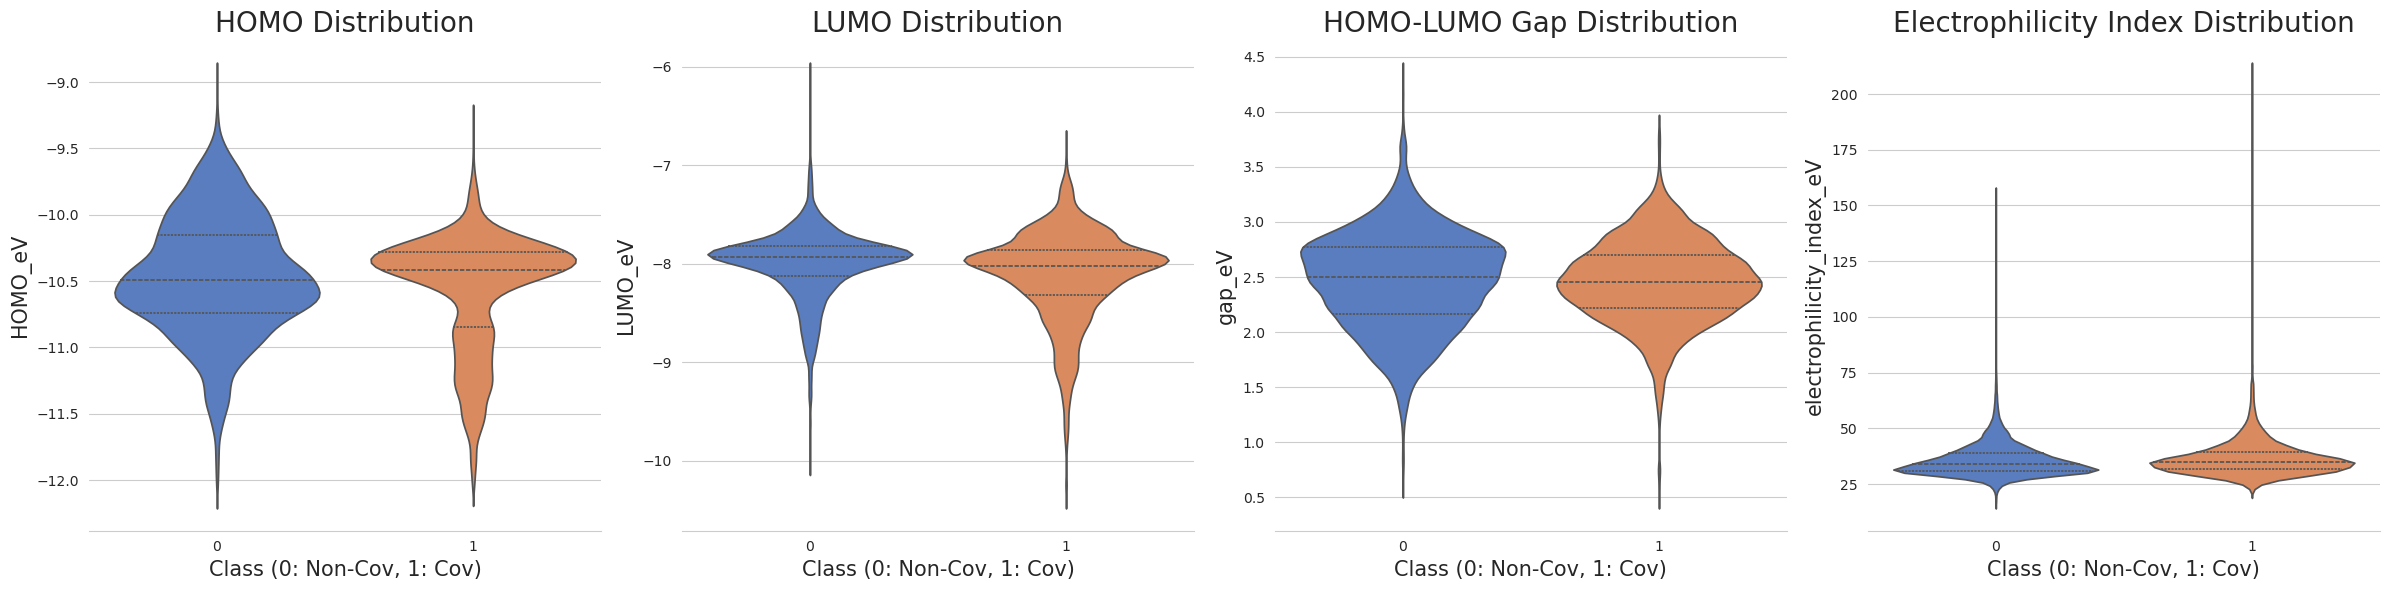

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check if final_df is available
if 'final_df' not in locals():
    if os.path.exists('qm_augmented_classification_dataset.csv'):
        final_df = pd.read_csv('qm_augmented_classification_dataset.csv')
    else:
        raise ValueError("final_df not found. Please run the data loading cell first.")

# Set up the matplotlib figure
f, axes = plt.subplots(1, 4, figsize=(24, 6), sharex=True)
sns.despine(left=True)

# Define plotting parameters
properties = ['HOMO_eV', 'LUMO_eV', 'gap_eV', 'electrophilicity_index_eV']
titles = ['HOMO Distribution', 'LUMO Distribution', 'HOMO-LUMO Gap Distribution', 'Electrophilicity Index Distribution']
colors = ['skyblue', 'lightgreen', 'salmon', 'violet']

for i, prop in enumerate(properties):
    sns.violinplot(x='cov_crbn_label', y=prop, data=final_df, ax=axes[i], 
                   palette="muted", inner="quartile")
    axes[i].set_title(titles[i], fontsize=20)
    axes[i].set_xlabel('Class (0: Non-Cov, 1: Cov)', fontsize=15)
    axes[i].set_ylabel(prop, fontsize=15)

plt.tight_layout()
plt.show()

In [62]:
from scipy import stats

# Ensure data is split
class_0_data = final_df[final_df['cov_crbn_label'] == 0]
class_1_data = final_df[final_df['cov_crbn_label'] == 1]

print("Statistical Significance Test (Mann-Whitney U Test)")
print(f"Class 0 (Non-Covalent): n={len(class_0_data)}")
print(f"Class 1 (Covalent):     n={len(class_1_data)}")
print("-" * 60)

properties = ['HOMO_eV', 'LUMO_eV', 'gap_eV', 'electrophilicity_index_eV']

for prop in properties:
    # Get values
    vals_0 = class_0_data[prop].dropna()
    vals_1 = class_1_data[prop].dropna()
    
    # Perform Mann-Whitney U test
    # We use this instead of t-test as distributions might not be perfectly normal
    stat, p_value = stats.mannwhitneyu(vals_0, vals_1, alternative='two-sided')
    
    # Calculate means for context
    mean_0 = vals_0.mean()
    mean_1 = vals_1.mean()
    
    print(f"\nProperty: {prop}")
    print(f"  Mean Class 0: {mean_0:.4f} eV")
    print(f"  Mean Class 1: {mean_1:.4f} eV")
    print(f"  Difference:   {mean_1 - mean_0:.4f} eV")
    print(f"  U-statistic:  {stat}")
    print(f"  P-value:      {p_value:.4e}")
    
    if p_value < 0.05:
        print("  Result:       Significant Difference (p < 0.05)")
    else:
        print("  Result:       No Significant Difference")

Statistical Significance Test (Mann-Whitney U Test)
Class 0 (Non-Covalent): n=8733
Class 1 (Covalent):     n=7268
------------------------------------------------------------

Property: HOMO_eV
  Mean Class 0: -10.4677 eV
  Mean Class 1: -10.5734 eV
  Difference:   -0.1057 eV
  U-statistic:  33640822.0
  P-value:      5.8176e-11
  Result:       Significant Difference (p < 0.05)

Property: LUMO_eV
  Mean Class 0: -8.0039 eV
  Mean Class 1: -8.1193 eV
  Difference:   -0.1154 eV
  U-statistic:  36660431.0
  P-value:      2.8174e-64
  Result:       Significant Difference (p < 0.05)

Property: gap_eV
  Mean Class 0: 2.4638 eV
  Mean Class 1: 2.4541 eV
  Difference:   -0.0097 eV
  U-statistic:  32548459.0
  P-value:      5.2125e-03
  Result:       Significant Difference (p < 0.05)

Property: electrophilicity_index_eV
  Mean Class 0: 35.8635 eV
  Mean Class 1: 36.8002 eV
  Difference:   0.9367 eV
  U-statistic:  29295356.0
  P-value:      4.9361e-17
  Result:       Significant Difference (p <